# PTB-XL ECG Classification — TCN Pipeline

This notebook builds the data pipeline for an upgraded ECG classification system using
a **Temporal Convolutional Network (TCN)** in TensorFlow/Keras, trained on the
**PTB-XL** 12-lead ECG dataset.

**Scope of this notebook:**
1. Environment setup
2. Loading and labeling PTB-XL records (5 diagnostic superclasses)
3. Visual EDA — time domain & frequency domain (FFT), pre-filtering
4. Preprocessing pipeline — bandpass filter, notch filter, normalization
5. Building `tf.data.Dataset` objects ready to feed into a model

> Model architecture and training are intentionally **not** included here — this notebook
> stops once `train_ds`, `val_ds`, and `test_ds` are ready to consume.


## 1. Get the Dataset (Drive First, Download as Fallback)

This checks your Google Drive for an existing `ptb-xl-dataset` folder first.
If found, it's used directly — no download needed. If not found, the dataset
is downloaded fresh from PhysioNet (~1.7GB, takes a while) and saved to
`ptb-xl/` in the local Colab runtime.

> Edit `DRIVE_DATASET_PATH` below if your folder is named differently or
> lives somewhere other than directly in `My Drive`.


In [ ]:
# Mount Google Drive (skipped automatically if not running in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab - skipping Drive mount.")


Mounted at /content/drive


In [ ]:
import os

# Path to the dataset folder inside your Google Drive (edit if needed)
DRIVE_DATASET_PATH = "/content/drive/MyDrive/ptb-xl-dataset"

# Local fallback path used if the dataset has to be downloaded fresh
LOCAL_DATASET_PATH = "ptb-xl"

def _looks_like_ptbxl(path):
    """Quick sanity check that a folder actually contains the PTB-XL files."""
    required = ["ptbxl_database.csv", "scp_statements.csv", "records100", "records500"]
    return all(os.path.exists(os.path.join(path, f)) for f in required)


if IN_COLAB and os.path.isdir(DRIVE_DATASET_PATH) and _looks_like_ptbxl(DRIVE_DATASET_PATH):
    print(f"Found PTB-XL dataset in Drive: {DRIVE_DATASET_PATH}")
    PTBXL_PATH = DRIVE_DATASET_PATH

elif _looks_like_ptbxl(LOCAL_DATASET_PATH):
    print(f"Found PTB-XL dataset already on local disk: {LOCAL_DATASET_PATH}")
    PTBXL_PATH = LOCAL_DATASET_PATH

else:
    print("Dataset not found in Drive or locally - downloading from PhysioNet...")
    print("This is a ~1.7GB file and may take a while.")

    import zipfile
    import shutil

    os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)
    url = (
        "https://physionet.org/static/published-projects/ptb-xl/"
        "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"
    )

    !wget -O ptbxl_data.zip {url}

    print("Extracting files...")
    with zipfile.ZipFile("ptbxl_data.zip", "r") as zip_ref:
        zip_ref.extractall("ptb-xl-temp")

    src = "ptb-xl-temp/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"
    for item in os.listdir(src):
        shutil.move(os.path.join(src, item), f"{LOCAL_DATASET_PATH}/")

    !rm -rf ptbxl_data.zip ptb-xl-temp

    PTBXL_PATH = LOCAL_DATASET_PATH
    print(f"Dataset downloaded and ready in {PTBXL_PATH}/")

    print(
        "\nTip: to skip this download next time, copy the '" + LOCAL_DATASET_PATH +
        "' folder into your Google Drive as 'ptb-xl-dataset' "
        "(My Drive > ptb-xl-dataset)."
    )

print(f"\nUsing PTBXL_PATH = {PTBXL_PATH}")


Found PTB-XL dataset in Drive: /content/drive/MyDrive/ptb-xl-dataset

Using PTBXL_PATH = /content/drive/MyDrive/ptb-xl-dataset


### Copy Dataset to Local Disk (Recommended, 100Hz Only)

Reading thousands of small files directly from a mounted Google Drive
(`/content/drive/...`) is much slower than reading from Colab's local SSD,
because each file open crosses the Drive FUSE filesystem individually.
Copying the dataset to local disk **once** with a bulk copy is typically
far faster overall than leaving every later `wfdb.rdsamp` call to hit
Drive directly.

**This pipeline only uses the 100 Hz records** (`records100/`, via
`filename_lr`), so `records500/` is skipped entirely during the copy —
no point copying ~2.5GB of 500 Hz data that's never read. Only the CSVs
and `records100/` are copied.

This cell also runs a **completeness check** against `ptbxl_database.csv`
(100 Hz files only) before continuing — if any record file is missing
(e.g. an incomplete Drive upload), it's reported here immediately instead
of failing hours into the preprocessing loop.


In [ ]:
import shutil
import pandas as pd

LOCAL_COPY_PATH = "/content/ptb-xl-local"

# Only these are needed for the 100 Hz pipeline - records500/ is skipped on purpose
REQUIRED_ITEMS = ["ptbxl_database.csv", "scp_statements.csv", "records100"]

if PTBXL_PATH != LOCAL_COPY_PATH:
    if os.path.isdir(LOCAL_COPY_PATH):
        print(f"Local copy already exists at {LOCAL_COPY_PATH} - skipping copy.")
    else:
        print(f"Copying 100Hz dataset from {PTBXL_PATH} to {LOCAL_COPY_PATH} ...")
        print("Skipping records500/ since this pipeline only uses the 100Hz records.")
        os.makedirs(LOCAL_COPY_PATH, exist_ok=True)
        for item in REQUIRED_ITEMS:
            src_path = os.path.join(PTBXL_PATH, item)
            dst_path = os.path.join(LOCAL_COPY_PATH, item)
            if os.path.isdir(src_path):
                shutil.copytree(src_path, dst_path)
            else:
                shutil.copy2(src_path, dst_path)
        print("Copy complete (100Hz only).")
    PTBXL_PATH = LOCAL_COPY_PATH
else:
    print("Already using local disk - no copy needed.")

print(f"\nUsing PTBXL_PATH = {PTBXL_PATH}")

# ── Completeness check (100Hz only) ──
# Verify every record referenced in ptbxl_database.csv has both its .hea
# and .dat files on disk for the 100Hz version. Catches incomplete Drive
# uploads / interrupted downloads immediately, instead of failing partway
# through the slow preprocessing loop.
print("\nVerifying 100Hz dataset completeness (this takes a few seconds)...")

_meta = pd.read_csv(os.path.join(PTBXL_PATH, "ptbxl_database.csv"), usecols=["filename_lr"])

missing = []
for rel_path in _meta["filename_lr"]:
    base = os.path.join(PTBXL_PATH, rel_path)
    for ext in (".hea", ".dat"):
        if not os.path.exists(base + ext):
            missing.append(base + ext)

if missing:
    print(f"WARNING: {len(missing)} record file(s) are missing. First few:")
    for m in missing[:10]:
        print("  -", m)
    print(
        "\nThe dataset on disk is incomplete - re-sync/re-upload it to Drive, "
        "or delete the local copy and re-download with the cell above."
    )
else:
    print(f"All {len(_meta) * 2:,} record files present for the 100Hz version. Dataset is complete.")


Copying 100Hz dataset from /content/drive/MyDrive/ptb-xl-dataset to /content/ptb-xl-local ...
Skipping records500/ since this pipeline only uses the 100Hz records.


## 2. Environment Setup

Run this once per environment. Versions are pinned to avoid NumPy/TensorFlow ABI
conflicts with `wfdb`.


In [ ]:
# Core deep learning
!pip install tensorflow

# ECG/WFDB handling
!pip install wfdb==4.1.2

# Scientific stack - Pinning pandas to 2.2.2 to fix the ArrowStringArray error in wfdb
!pip install "numpy>=2.0.0" "scipy>=1.13.0" "pandas==2.2.2" "matplotlib>=3.8.2" "scikit-learn>=1.4.0"

# Optional: progress bars
!pip install tqdm

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Imports


In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import wfdb
import scipy.signal as signal
import matplotlib.pyplot as plt
from tqdm import tqdm


## 4. Load PTB-XL Metadata and Map SCP Codes to Superclasses

PTB-XL is multi-label: each record can have multiple SCP-ECG diagnostic statements,
which roll up into 5 diagnostic superclasses: `NORM`, `MI`, `STTC`, `CD`, `HYP`.

**Set `PTBXL_PATH` below** to wherever the dataset lives.


In [ ]:
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
print(f"Superclasses: {SUPERCLASSES}")


Superclasses: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


In [ ]:
Y = pd.read_csv(os.path.join(PTBXL_PATH, "ptbxl_database.csv"), index_col="ecg_id")
Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

agg_df = pd.read_csv(os.path.join(PTBXL_PATH, "scp_statements.csv"), index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(scp_dict):
    classes = set()
    for code_ in scp_dict.keys():
        if code_ in agg_df.index:
            classes.add(agg_df.loc[code_].diagnostic_class)
    return list(classes)

Y["diagnostic_superclass"] = Y.scp_codes.apply(aggregate_diagnostic)

print(f"Total records: {len(Y)}")
Y[["scp_codes", "diagnostic_superclass"]].head()


Total records: 21799


,scp_codes,diagnostic_superclass
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [ ]:
single_label = Y[Y.diagnostic_superclass.apply(len) == 1].copy()
single_label["label"] = single_label.diagnostic_superclass.apply(lambda x: x[0])

print("Pure single-label record counts per class:")
print(single_label["label"].value_counts())


Pure single-label record counts per class:
label
NORM    9069
MI      2532
STTC    2400
CD      1708
HYP      535
Name: count, dtype: int64


In [ ]:
representative_records = {}
for sc in SUPERCLASSES:
    subset = single_label[single_label.label == sc]
    if len(subset) > 0:
        representative_records[sc] = subset.iloc[0]
    else:
        print(f"Warning: no pure single-label record found for {sc}")

representative_records


{'NORM': patient_id                                                       15709.0
 age                                                                 56.0
 sex                                                                    1
 height                                                               NaN
 weight                                                              63.0
 nurse                                                                2.0
 site                                                                 0.0
 device                                                         CS-12   E
 recording_date                                       1984-11-09 09:17:34
 report                            sinusrhythmus periphere niederspannung
 scp_codes                       {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
 heart_axis                                                           NaN
 infarction_stadium1                                                  NaN
 infarction_stadium2          

## 5. Visual EDA — Time Domain vs. Frequency Domain (Pre-Filtering)


In [ ]:
def plot_time_and_frequency_domain(signal_raw, fs=100, title="ECG Analysis"):
    lead_signal = signal_raw[:, 0]
    n = len(lead_signal)
    time = np.arange(n) / fs

    fft_vals = np.fft.fft(lead_signal)
    fft_freqs = np.fft.fftfreq(n, d=1 / fs)
    pos_mask = fft_freqs >= 0
    frequencies = fft_freqs[pos_mask]
    fft_magnitude = np.abs(fft_vals)[pos_mask] / n

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(time, lead_signal, color='b', lw=1.2)
    axes[0].set_title(f"{title} - Time Domain")
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel("Amplitude (mV)")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].plot(frequencies, fft_magnitude, color='r', lw=1.2)
    axes[1].set_title(f"{title} - Frequency Spectrum (FFT)")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Magnitude")
    axes[1].set_xlim(0, fs / 2)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


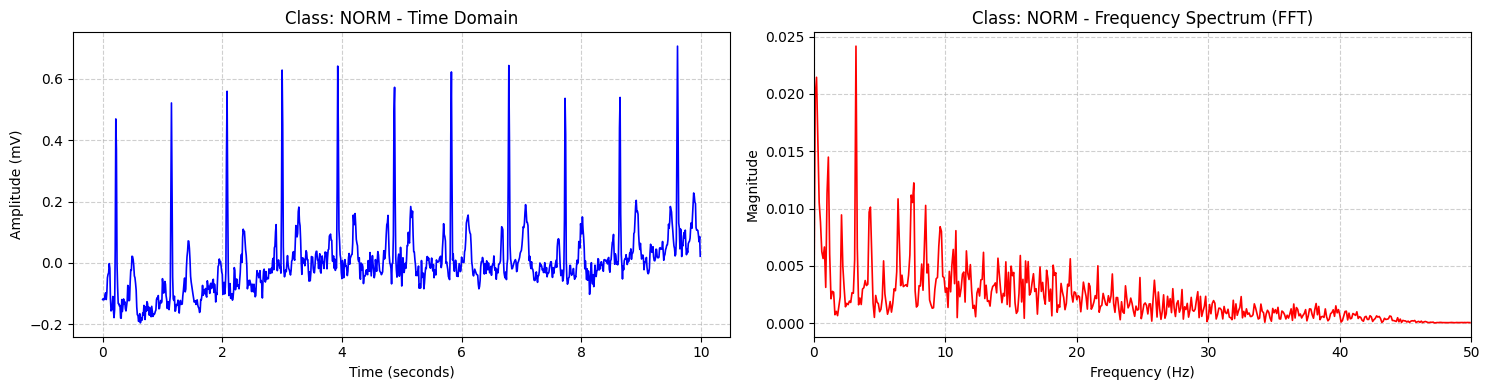

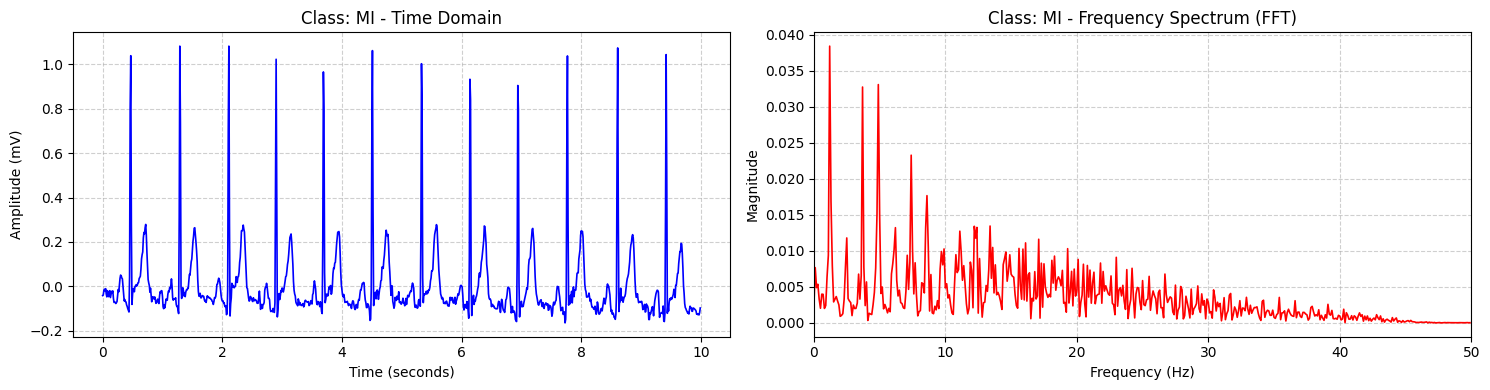

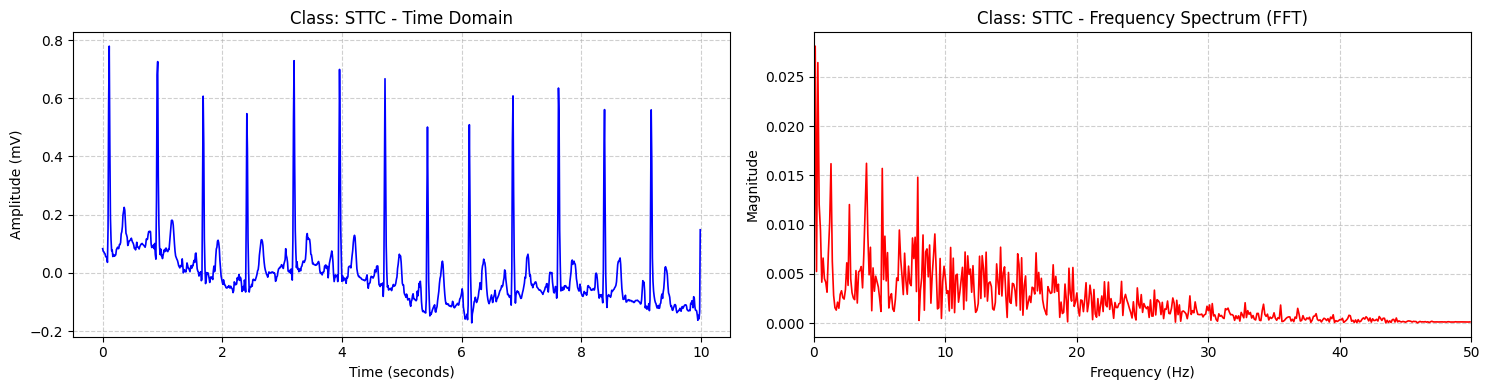

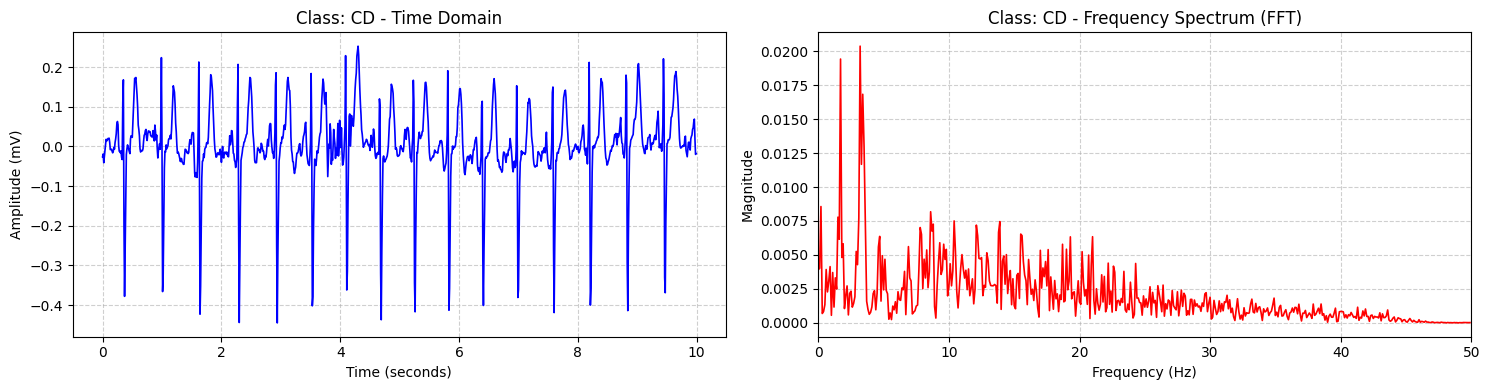

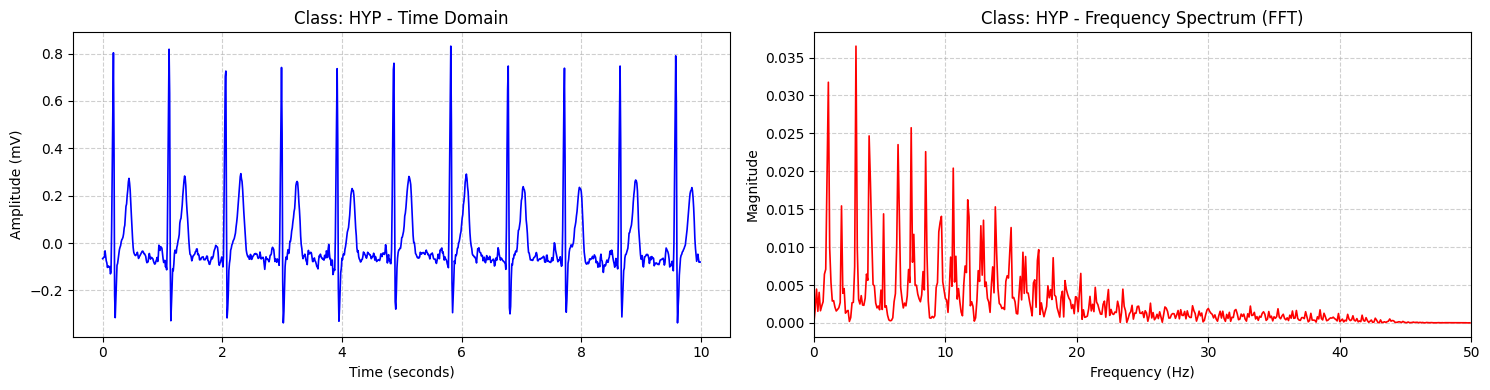

In [ ]:
for sc, row in representative_records.items():
    record_path = os.path.join(PTBXL_PATH, row["filename_lr"])
    signal_raw, meta = wfdb.rdsamp(record_path)
    plot_time_and_frequency_domain(signal_raw, fs=100, title=f"Class: {sc}")


## 6. Preprocessing Pipeline

Steps applied per record, per lead:
1. **Zero-phase Butterworth bandpass filter** (0.5–40 Hz)
2. **Notch filter at 50 Hz**
3. **Channel-wise z-score normalization**


In [ ]:
def tf_preprocess_pipeline(raw_waveform, fs=100):
    """
    Bandpass + notch filter + per-channel z-score normalization.

    BUG FIX: at fs=100, the Nyquist frequency is exactly 50 Hz, which is the
    same frequency as the notch filter target. A notch filter AT the Nyquist
    limit is mathematically degenerate (the filter design becomes unstable
    and filtfilt amplifies that instability instead of suppressing 50 Hz
    hum). This was distorting the QRS complex and inflating R-peak amplitude
    in the "after preprocessing" plot. The notch filter is now only applied
    when fs is high enough to give it real headroom below Nyquist.
    """
    nyq = 0.5 * fs

    # 1. Bandpass filter (0.5-40 Hz) - safe at both 100 Hz and 500 Hz
    b, a = signal.butter(4, [0.5 / nyq, 40.0 / nyq], btype='band')
    filtered = signal.filtfilt(b, a, raw_waveform, axis=0)

    # 2. Notch filter at 50 Hz - ONLY valid when fs gives enough headroom
    #    below Nyquist. At fs=100, Nyquist=50Hz, so the notch sits right on
    #    the boundary and breaks. Skip it at 100 Hz; PTB-XL's 100 Hz records
    #    are pre-decimated by PhysioNet and already largely free of mains
    #    hum, so skipping the notch here is safe. Use the 500 Hz records
    #    (filename_hr) if you need the notch filter to actually do something.
    if fs > 100:
        b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
        filtered = signal.filtfilt(b_notch, a_notch, filtered, axis=0)

    # 3. Channel-wise z-score normalization
    mean = np.mean(filtered, axis=0, keepdims=True)
    std = np.std(filtered, axis=0, keepdims=True) + 1e-8
    normalized = (filtered - mean) / std

    return normalized.astype(np.float32)

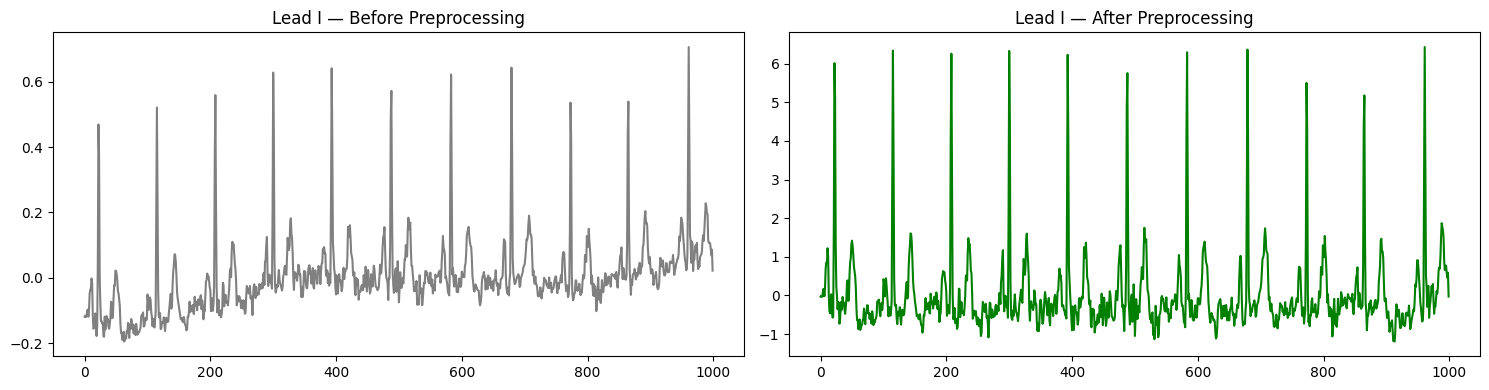

In [ ]:
sample_row = representative_records["NORM"]
raw_sample, _ = wfdb.rdsamp(os.path.join(PTBXL_PATH, sample_row["filename_lr"]))
filtered_sample = tf_preprocess_pipeline(raw_sample, fs=100)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(raw_sample[:, 0], color='gray')
axes[0].set_title("Lead I — Before Preprocessing")
axes[1].plot(filtered_sample[:, 0], color='green')
axes[1].set_title("Lead I — After Preprocessing")
plt.tight_layout()
plt.show()


### Spectrogram Comparison — Before vs. After Filtering

A spectrogram shows how the signal's frequency content evolves over time
(unlike the single static FFT used in the EDA section above). This is a
direct way to see whether the bandpass + notch filtering is actually doing
its job: baseline wander should disappear from the low end, and (when the
notch filter is active) the 50 Hz powerline line should vanish from the
high-frequency band.


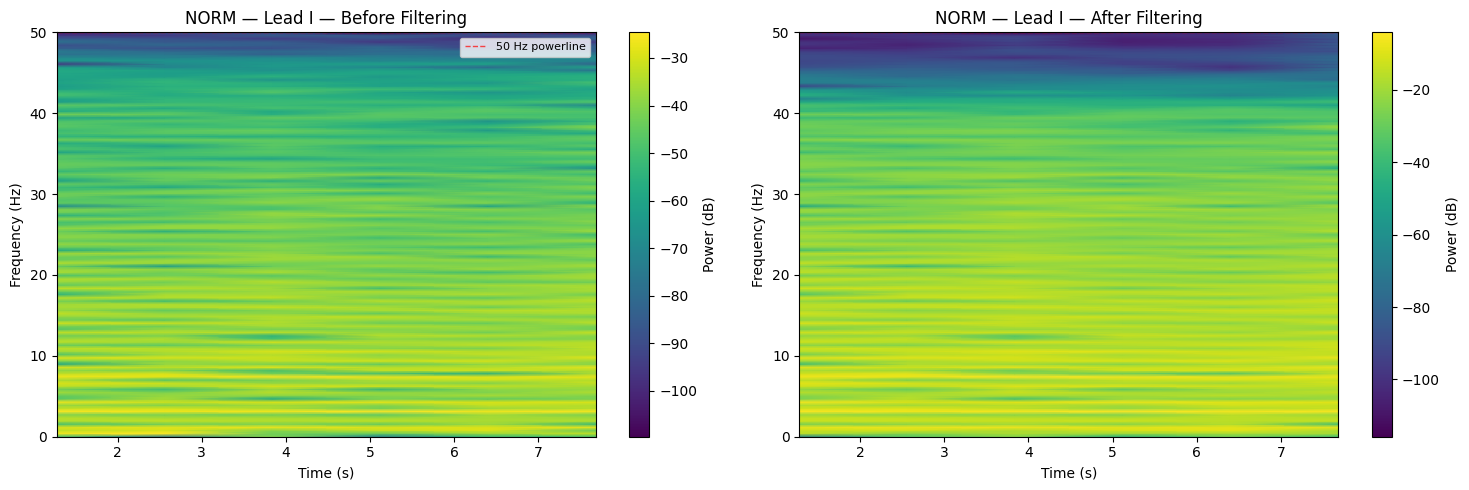

In [ ]:
def plot_spectrogram_comparison(raw_waveform, filtered_waveform, fs=100, lead_idx=0, title="ECG"):
    """
    Plot side-by-side spectrograms of a single lead, before and after filtering.

    raw_waveform, filtered_waveform: arrays of shape (Time_Steps, Leads)
    fs: sampling rate in Hz
    lead_idx: which lead/channel to visualize (0 = Lead I)
    """
    raw_lead = raw_waveform[:, lead_idx]
    filt_lead = filtered_waveform[:, lead_idx]

    # nperseg must not exceed the signal length; PTB-XL records are short
    # (1000 samples at 100 Hz, 5000 at 500 Hz), so cap the window accordingly.
    nperseg = min(256, len(raw_lead))
    noverlap = nperseg // 2

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    f1, t1, Sxx1 = signal.spectrogram(raw_lead, fs=fs, nperseg=nperseg, noverlap=noverlap)
    pcm1 = axes[0].pcolormesh(t1, f1, 10 * np.log10(Sxx1 + 1e-12), shading="gouraud", cmap="viridis")
    axes[0].set_title(f"{title} — Before Filtering")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Frequency (Hz)")
    axes[0].set_ylim(0, fs / 2)
    fig.colorbar(pcm1, ax=axes[0], label="Power (dB)")

    f2, t2, Sxx2 = signal.spectrogram(filt_lead, fs=fs, nperseg=nperseg, noverlap=noverlap)
    pcm2 = axes[1].pcolormesh(t2, f2, 10 * np.log10(Sxx2 + 1e-12), shading="gouraud", cmap="viridis")
    axes[1].set_title(f"{title} — After Filtering")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Frequency (Hz)")
    axes[1].set_ylim(0, fs / 2)
    fig.colorbar(pcm2, ax=axes[1], label="Power (dB)")

    # Mark the 50 Hz powerline frequency for reference, when it's within range
    if fs / 2 >= 50:
        for ax in axes:
            ax.axhline(50, color="red", linestyle="--", linewidth=1, alpha=0.7, label="50 Hz powerline")
        axes[0].legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_spectrogram_comparison(raw_sample, filtered_sample, fs=100, lead_idx=0, title="NORM — Lead I")


In [ ]:
def build_multihot_labels(df, superclasses):
    label_matrix = np.zeros((len(df), len(superclasses)), dtype=np.float32)
    for i, classes in enumerate(df.diagnostic_superclass):
        for c in classes:
            if c in superclasses:
                label_matrix[i, superclasses.index(c)] = 1.0
    return label_matrix

def load_and_preprocess_dataset(df, ptbxl_path, fs=100, path_col="filename_lr"):
    X = np.stack([
        tf_preprocess_pipeline(wfdb.rdsamp(os.path.join(ptbxl_path, fname))[0], fs=fs)
        for fname in tqdm(df[path_col], desc="Loading + preprocessing")
    ])
    y = build_multihot_labels(df, SUPERCLASSES)
    return X, y


### Train / Validation / Test Split

- Folds 1–8 → train
- Fold 9 → validation
- Fold 10 → test


In [ ]:
train_df = Y[Y.strat_fold <= 8]
val_df   = Y[Y.strat_fold == 9]
test_df  = Y[Y.strat_fold == 10]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 17418 | Val: 2183 | Test: 2198


### Load (or Build + Cache) the Preprocessed Arrays

`load_and_preprocess_dataset` is slow — it reads and filters every record
one at a time (roughly 3-4 hours total across train/val/test at 500 Hz).
Doing that on every single session is wasteful, so the cell below caches
the finished arrays to Google Drive as `.npy` files.

**How it works:**
- First run: no cache found → runs the full preprocessing pipeline, then
  saves the results to `CACHE_DIR` in Drive.
- Every run after that: cache found → loads directly from Drive in a few
  seconds, skipping preprocessing entirely.

> If you ever change `tf_preprocess_pipeline`, `SAMPLING_RATE`, or which
> folds go into which split, delete the cached `.npy` files (or change
> `CACHE_VERSION` below) so the cache gets rebuilt with the new logic
> instead of silently serving stale arrays.


In [ ]:
import time

CACHE_DIR = "/content/drive/MyDrive/ptb-xl-dataset/preprocessed_cache"
CACHE_VERSION = "v1"  # bump this if tf_preprocess_pipeline or the split logic changes

def _cache_paths(split_name):
    base = f"{CACHE_DIR}/{CACHE_VERSION}_{split_name}"
    return {
        "X": f"{base}_X.npy",
        "y": f"{base}_y.npy",
    }

def _cache_exists(split_name):
    paths = _cache_paths(split_name)
    return os.path.exists(paths["X"]) and os.path.exists(paths["y"])

def load_or_build_split(df, split_name, ptbxl_path):
    """
    Load a (X, y) split from the Drive cache if available, otherwise build
    it from scratch with load_and_preprocess_dataset and save it to Drive
    for next time.
    """
    paths = _cache_paths(split_name)

    if _cache_exists(split_name):
        print(f"[{split_name}] Loading cached arrays from Drive...")
        X = np.load(paths["X"])
        y = np.load(paths["y"])
        print(f"[{split_name}] Loaded from cache: X={X.shape} y={y.shape}")
        return X, y

    print(f"[{split_name}] No cache found - running preprocessing (this will take a while)...")
    start = time.time()
    X, y = load_and_preprocess_dataset(df, ptbxl_path)
    elapsed = time.time() - start
    print(f"[{split_name}] Preprocessing finished in {elapsed/60:.1f} min: X={X.shape} y={y.shape}")

    os.makedirs(CACHE_DIR, exist_ok=True)
    print(f"[{split_name}] Saving to Drive cache: {paths['X']}")
    np.save(paths["X"], X)
    np.save(paths["y"], y)
    print(f"[{split_name}] Cached for next time.")

    return X, y


X_train, y_train = load_or_build_split(train_df, "train", PTBXL_PATH)
X_val,   y_val    = load_or_build_split(val_df,   "val",   PTBXL_PATH)
X_test,  y_test   = load_or_build_split(test_df,  "test",  PTBXL_PATH)

print("\nFinal shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)


[train] Loading cached arrays from Drive...
[train] Loaded from cache: X=(17418, 1000, 12) y=(17418, 5)
[val] Loading cached arrays from Drive...
[val] Loaded from cache: X=(2183, 1000, 12) y=(2183, 5)
[test] Loading cached arrays from Drive...
[test] Loaded from cache: X=(2198, 1000, 12) y=(2198, 5)

Final shapes:
X_train: (17418, 1000, 12) y_train: (17418, 5)
X_val:   (2183, 1000, 12) y_val:   (2183, 5)
X_test:  (2198, 1000, 12) y_test:  (2198, 5)


### Building `tf.data.Dataset` Objects, with Training-Only Augmentation

To fight the overfitting seen in the first training run (train loss kept
falling while val loss plateaued around epoch 20-25), light physiological
augmentation is applied to `train_ds` only - never to `val_ds` or
`test_ds`, since augmenting evaluation data would corrupt the metrics.

Three augmentations, applied per-batch on the fly (not precomputed, so
every epoch sees slightly different noise):
- **Amplitude scaling** - small random per-sample gain, simulating
  electrode contact / lead placement variation.
- **Gaussian noise** - simulates muscle artifact / electrical noise.
- **Time shift** - small random circular shift along the time axis,
  simulating imperfect R-peak alignment between records.

All three are mild by design - aggressive augmentation on ECGs risks
distorting the diagnostic morphology itself (the exact shape of the QRS
complex, ST segment, etc. is what carries the label's meaning).


In [ ]:
def augment_ecg(x, y, noise_std=0.03, scale_range=0.1, max_shift=20):
    scale = tf.random.uniform(
        [tf.shape(x)[0], 1, 1], minval=1.0 - scale_range, maxval=1.0 + scale_range
    )
    x = x * scale
    x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=noise_std)
    shift = tf.random.uniform([], minval=-max_shift, maxval=max_shift, dtype=tf.int32)
    x = tf.roll(x, shift=shift, axis=1)
    return x, y

def make_dataset(X, y, batch_size=64, shuffle=False, augment=False, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=seed)
    ds = ds.batch(batch_size)
    if augment:
        ds = ds.map(augment_ecg, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

# ── Oversampling HYP-positive training windows ───────────────────────────
HYP_INDEX = SUPERCLASSES.index("HYP")
OVERSAMPLE_FACTOR = 3  # Target: 3x total HYP presence

hyp_positive_idx = np.where(y_train[:, HYP_INDEX] == 1)[0]
extra_idx = np.tile(hyp_positive_idx, OVERSAMPLE_FACTOR - 1)

# Build the oversampled training arrays
X_train_os = np.concatenate([X_train, X_train[extra_idx]], axis=0)
y_train_os = np.concatenate([y_train, y_train[extra_idx]], axis=0)

print(f"Verification - Oversampling:")
print(f"  Original train size: {len(X_train)} | HYP positives: {len(hyp_positive_idx)}")
print(f"  Oversampled train size: {len(X_train_os)} | HYP positives: {int(y_train_os[:, HYP_INDEX].sum())}")

# Create final dataset objects
train_ds = make_dataset(X_train_os, y_train_os, shuffle=True, augment=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)

# Peek at batch structure
for batch_x, batch_y in train_ds.take(1):
    print("\nBatch X shape:", batch_x.shape)
    print("Batch y shape:", batch_y.shape)

Verification - Oversampling:
  Original train size: 17418 | HYP positives: 2119
  Oversampled train size: 21656 | HYP positives: 6357

Batch X shape: (64, 1000, 12)
Batch y shape: (64, 5)


### Class Balance Check


Positive label counts per superclass (training set):
NORM    7596.0
MI      4379.0
STTC    4186.0
CD      3907.0
HYP     2119.0
dtype: float32


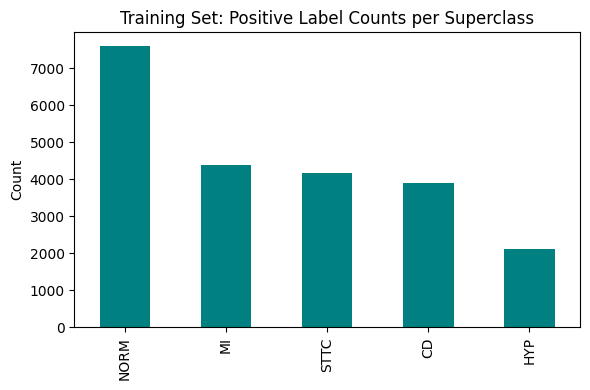

In [ ]:
label_counts = pd.DataFrame(y_train, columns=SUPERCLASSES).sum().sort_values(ascending=False)
print("Positive label counts per superclass (training set):")
print(label_counts)

label_counts.plot(kind="bar", figsize=(6, 4), color="teal")
plt.title("Training Set: Positive Label Counts per Superclass")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 7. TCN Model — Architecture, Training, and Evaluation

This builds the Temporal Convolutional Network (TCN) that consumes
`train_ds` / `val_ds` / `test_ds` from the data pipeline above.

**Why a TCN here:** the project originally specified a CNN-BiLSTM-Attention
hybrid, but this notebook uses a TCN instead — dilated causal 1D
convolutions give a similarly large receptive field over the 1000-sample
(10s @ 100Hz) window without the sequential bottleneck of recurrent layers,
train faster, and are easier to make latency-predictable for a real-time
monitoring system like CardioGuard.

**Task setup:**
- Multi-label classification, 5 superclasses (`NORM, MI, STTC, CD, HYP`) —
  a record can carry more than one label, so this uses sigmoid outputs +
  binary cross-entropy, not softmax + categorical cross-entropy.
- Input shape: `(1000, 12)` — 1000 timesteps (10s @ 100Hz) × 12 ECG leads.
- Class imbalance is real here (`NORM`: 7,596 positives vs `HYP`: 2,119 in
  training) — handled below with class weighting in the loss.


###Custom Multi-Head Temporal Context Attention (v4 — XAI Integration)

This version extends the previous temporal attention mechanism by introducing a Multi-Head Self-Attention module, enabling the model to capture multiple temporal dependency patterns across the ECG signal while preserving interpretability for the downstream XAI pipeline.

- Replaced the single-head attention mechanism with a custom MultiHeadAttentionLayer, allowing the model to learn complementary temporal relationships through multiple attention heads before aggregating the contextual representations.
- Applied GlobalAveragePooling1D after the Multi-Head Attention layer, summarizing the enriched contextual features instead of directly averaging the original LSTM outputs. This preserves the benefits of attention while producing a compact feature vector for classification.
- Configured a dual-output architecture that returns both the 5-class disease probabilities and the averaged temporal attention weights `(sequence_length, 1)`. The attention maps are obtained by averaging across all attention heads and query positions, providing an interpretable importance score for each ECG timestep.
- Decoupled the training objective by applying the loss function only to the classification output `(loss=[weighted_focal_loss, None])`. Consequently, the attention weights are learned implicitly through backpropagation without requiring explicit supervision, while remaining available for post-hoc visualization and explainability analyses.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

class MultiHeadAttentionLayer(layers.Layer):
    def __init__(self, num_heads=1, return_attention_weights=False, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.return_attention_weights = return_attention_weights

    def build(self, input_shape):
        d_model = input_shape[-1]  # 64
        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=d_model // self.num_heads  # to be flixble to change #of heads
        )
        self.pooling = layers.GlobalAveragePooling1D()

    def call(self, x):
      context, weights = self.mha(x, x, x, return_attention_scores=True)
      pooled = self.pooling(context)

      if self.return_attention_weights:
          avg_weights = tf.reduce_mean(weights, axis=1)
          avg_weights = tf.reduce_mean(avg_weights, axis=-1, keepdims=True)
          return pooled, avg_weights
      return pooled

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "return_attention_weights": self.return_attention_weights
        })
        return config

### TCN Building Blocks (v2 — Stronger Regularization)

Changes from the first run, based on the overfitting pattern observed
(train loss kept falling past epoch 25 while val loss plateaued/climbed):

- **Spatial dropout raised from 0.2 to 0.3** inside each residual block.
- **Bottleneck widened from 64 to 128** (not 256 - a 4x jump risks adding
  overfitting capacity faster than the extra dropout can offset; widening
  more conservatively first and re-checking the train/val gap is safer).


In [ ]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.3, l2_reg=1e-4):
    """
    One TCN residual block: two dilated causal Conv1D layers with
    weight decay, ReLU, spatial dropout, and a residual connection.
    Causal padding ensures no information leaks from future timesteps -
    relevant if this model is later adapted for real-time streaming use.

    dropout_rate raised from 0.2 -> 0.3 (v2) to fight the overfitting seen
    in the first training run.
    """
    prev = x

    x = layers.Conv1D(
        filters, kernel_size, padding="causal", dilation_rate=dilation_rate,
        kernel_regularizer=regularizers.l2(l2_reg),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)

    x = layers.Conv1D(
        filters, kernel_size, padding="causal", dilation_rate=dilation_rate,
        kernel_regularizer=regularizers.l2(l2_reg),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)

    # Match channel dimensions for the residual add, if needed
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)

    return layers.Add()([prev, x])

def build_tcn(input_shape, num_classes, filters=64, kernel_size=7,
              dilations=(1, 2, 4, 8, 16, 32), dropout_rate=0.3, l2_reg=1e-4,
              bottleneck_units=128):
    """
    Full TCN model for multi-label ECG classification (v2) with Custom Attention.

    input_shape : (1000, 12)  - (Time_Steps, Leads)
    num_classes : 5           - NORM, MI, STTC, CD, HYP
    dilations   : exponentially increasing dilation rates.
    """
    inputs = layers.Input(shape=input_shape, name="ecg_input")

    x = layers.Conv1D(filters, 1, padding="same")(inputs)  # project to `filters` channels
    for d in dilations:
        x = tcn_residual_block(x, filters, kernel_size, dilation_rate=d, dropout_rate=dropout_rate, l2_reg=l2_reg)

    """
    V3 Architecture Changes:
    - Replaced GlobalAveragePooling1D with a custom AttentionLayer.
    - Reconfigured the model graph to output both classification predictions
      (diagnosis_output) and attention feature maps simultaneously.
    - Decoupled the training loop logic by routing the focal loss specifically
      to the primary classification output, bypassing the attention matrix.
    """
    attention_layer = MultiHeadAttentionLayer(return_attention_weights=True, name="two_head_attention")
    x, attention_weights = attention_layer(x)

    x = layers.Dense(bottleneck_units, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="sigmoid", name="diagnosis_output")(x)

    return models.Model(inputs, [outputs, attention_weights], name="ECG_TCN_Attention_v3")

### Build the Model


In [ ]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])  # (1000, 12)
NUM_CLASSES = len(SUPERCLASSES)

model = build_tcn(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    filters=64,
    kernel_size=7,
    dilations=(1, 2, 4, 8, 16, 32),
    dropout_rate=0.3,        # raised from 0.2
    bottleneck_units=128,    # raised from 64
)

model.summary()


Model: "ECG_TCN_Attention_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 64)  │        832 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1000, 64)  │          0 │ re_lu[0][0]       │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 1000, 64)  │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 64)  │          0 │ conv1d[0][0],     │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 1000, 64)  │          0 │ re_lu_2[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 1000, 64)  │          0 │ re_lu_3[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1000, 64)  │          0 │ add[0][0],      

 Total params: 374,341 (1.43 MB)

 Trainable params: 372,805 (1.42 MB)

 Non-trainable params: 1,536 (6.00 KB)

### Loss Function: Class-Weighted Focal Loss (v2)

The first run used plain weighted binary cross-entropy, which scales every
error by a fixed per-class weight regardless of how confidently wrong the
prediction was. HYP ended up with F1 of just 0.50 - the confusion matrix
showed the model behaving almost randomly on positive HYP cases (129 true
positives vs 133 false negatives), suggesting it wasn't being pushed hard
enough on the *specific, hard* HYP examples it was getting wrong.

**Focal loss** fixes this by adding a `(1 - p_t)^gamma` modulating term:
when the model is already confident and correct on an example (easy case,
mostly NORM), its contribution to the loss is suppressed; when the model
is wrong or uncertain (hard case, often HYP/CD), the loss contribution is
amplified. This is combined with the same inverse-frequency class weights
as before, so rare classes get weighted twice over: once for their overall
rarity, and again per-example for how hard they are to get right.


In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# 1. Inverse-frequency class weights computed on ORIGINAL distribution
# (Must run BEFORE oversampling to prevent dilution of HYP importance)
pos_counts = y_train.sum(axis=0)
neg_counts = y_train.shape[0] - pos_counts
class_weights = neg_counts / (pos_counts + 1e-8)
class_weights = class_weights / class_weights.mean()

print("Per-class weights (computed from original distribution):")
for sc, w in zip(SUPERCLASSES, class_weights):
    print(f"  {sc:6s}: {w:.3f}")

class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

# 2. Per-class focusing parameter (GAMMA_PER_CLASS)
GAMMA_PER_CLASS = {
    "NORM": 2.0,
    "MI":   2.0,
    "STTC": 2.0,
    "CD":   2.0,
    "HYP":  2.0,   # Increased for the specific minority class
}
gamma_tensor = tf.constant(
    [GAMMA_PER_CLASS[sc] for sc in SUPERCLASSES], dtype=tf.float32
)

def weighted_focal_loss(y_true, y_pred):
    """
    Class-weighted binary focal loss with per-class gamma.
    """
    y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())

    # Calculate p_t (probability of the ground truth class)
    p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)

    # Apply per-class gamma modulation
    focal_weight = tf.pow(1.0 - p_t, gamma_tensor)

    bce = -(
        class_weights_tensor * y_true * K.log(y_pred)
        + (1 - y_true) * K.log(1 - y_pred)
    )

    return K.mean(K.sum(focal_weight * bce, axis=-1))

Per-class weights (computed from original distribution):
  NORM  : 0.357
  MI    : 0.822
  STTC  : 0.873
  CD    : 0.955
  HYP   : 1.993


### Compile the Model

Metrics include per-threshold precision/recall plus AUC, since accuracy
alone is misleading for imbalanced multi-label classification - a model
that always predicts "no HYP" still scores high accuracy on that class.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=[weighted_focal_loss, None],
    metrics=[
        [
            tf.keras.metrics.AUC(name="auc", multi_label=True),
            tf.keras.metrics.Precision(name="precision", thresholds=0.5),
            tf.keras.metrics.Recall(name="recall", thresholds=0.5),
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.5),
        ],
        None
    ]
)


### Train (or Load) the Model

Same caching pattern as the dataset: checks Drive for an already-trained
final model first. If `ecg_tcn_final.keras` exists, it's loaded directly
and training is skipped entirely. Only if no saved model is found does it
train from scratch.

> If you change the architecture, loss, or data pipeline, delete the saved
> model in Drive (or bump `MODEL_VERSION` below) so this rebuilds instead
> of silently loading a stale model that no longer matches your code.


In [ ]:
import json

# Bumped to v2: architecture changed (wider bottleneck, higher dropout),
# loss changed (focal loss instead of plain weighted BCE),
# and the training data pipeline changed (augmentation added).
MODEL_VERSION = "v2"
MODEL_DIR = "/content/drive/MyDrive/ptb-xl-dataset/models"
FINAL_MODEL_PATH = f"{MODEL_DIR}/ecg_tcn_{MODEL_VERSION}_final.keras"
HISTORY_PATH = f"{MODEL_DIR}/ecg_tcn_{MODEL_VERSION}_history.json"
CHECKPOINT_PATH = f"/content/drive/MyDrive/ptb-xl-dataset/checkpoints/ecg_tcn_{MODEL_VERSION}_best.weights.h5"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

if os.path.exists(FINAL_MODEL_PATH) and os.path.exists(HISTORY_PATH):
    print(f"Found saved model at {FINAL_MODEL_PATH} - loading instead of retraining.")
    model = tf.keras.models.load_model(
        FINAL_MODEL_PATH,
        custom_objects={
            "weighted_focal_loss": weighted_focal_loss,
            "MultiHeadAttentionLayer": MultiHeadAttentionLayer
        }
    )
    with open(HISTORY_PATH) as f:
        history_data = json.load(f)

    class _HistoryStub:
        pass
    history = _HistoryStub()
    history.history = history_data

    print("Model and training history loaded from Drive. Skipped training.")

else:
    print("No saved model found in Drive - training from scratch.")

    # FIX: Updated monitor to match the prefixed name 'val_diagnosis_output_auc'
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_diagnosis_output_auc", mode="max", patience=10, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_diagnosis_output_auc", mode="max", factor=0.5, patience=5, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            CHECKPOINT_PATH, monitor="val_diagnosis_output_auc", mode="max", save_best_only=True,
            save_weights_only=True, verbose=1
        ),
    ]

    EPOCHS = 60

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    # Save the final model and training history to Drive immediately after training
    model.save(FINAL_MODEL_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)

    print(f"\nModel saved to {FINAL_MODEL_PATH}")
    print(f"Training history saved to {HISTORY_PATH}")

Found saved model at /content/drive/MyDrive/ptb-xl-dataset/models/ecg_tcn_v2_final.keras - loading instead of retraining.
Model and training history loaded from Drive. Skipped training.


### Training Curves


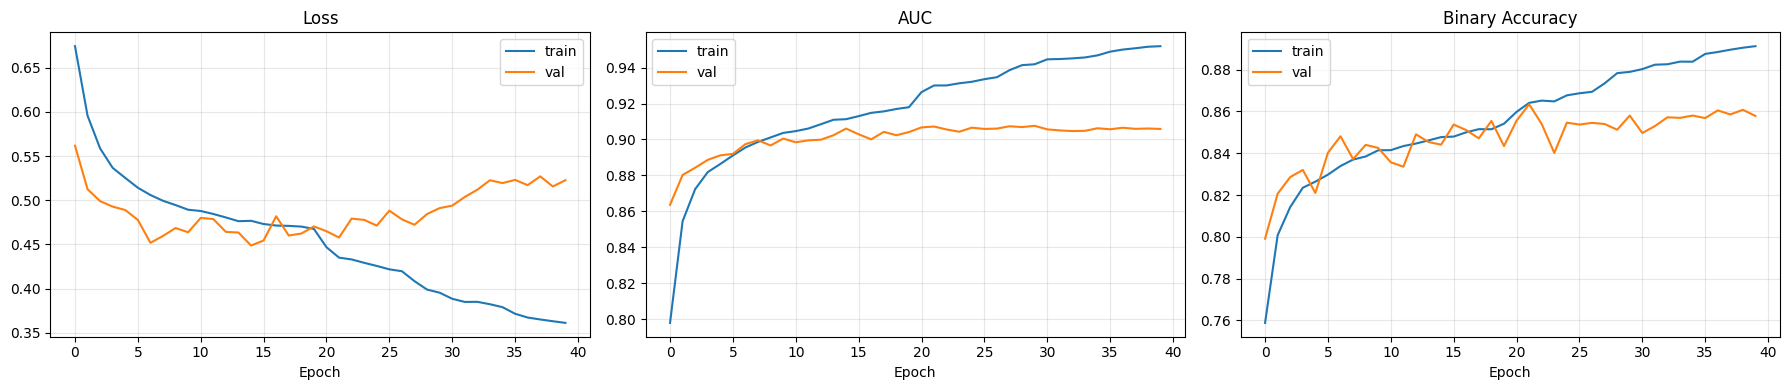

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["diagnosis_output_auc"], label="train")
axes[1].plot(history.history["val_diagnosis_output_auc"], label="val")
axes[1].set_title("AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history["diagnosis_output_binary_accuracy"], label="train")
axes[2].plot(history.history["val_diagnosis_output_binary_accuracy"], label="val")
axes[2].set_title("Binary Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Test Set Evaluation

Evaluation goes beyond a single accuracy number, since the project's
target metric is F1-score per arrhythmia class (CardioGuard's stated
target: >95% F1 across classes). Per-class precision, recall, and F1 are
reported individually, along with confusion matrices for each superclass
(since this is multi-label, a single combined confusion matrix isn't
meaningful - each class gets its own binary one-vs-rest view).


In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

y_test_pred_proba, test_attention_weights = model.predict(test_ds)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

print("Per-class classification report (threshold = 0.5):\n")
print(classification_report(y_test, y_test_pred, target_names=SUPERCLASSES, zero_division=0))

macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
micro_f1 = f1_score(y_test, y_test_pred, average="micro", zero_division=0)
print(f"Macro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")


35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step
Per-class classification report (threshold = 0.5):

              precision    recall  f1-score   support

        NORM       0.85      0.80      0.83       963
          MI       0.78      0.57      0.66       550
        STTC       0.76      0.68      0.72       521
          CD       0.82      0.58      0.68       496
         HYP       0.36      0.67      0.47       262

   micro avg       0.73      0.68      0.71      2792
   macro avg       0.71      0.66      0.67      2792
weighted avg       0.77      0.68      0.71      2792
 samples avg       0.67      0.68      0.66      2792

Macro F1: 0.6711
Micro F1: 0.7054


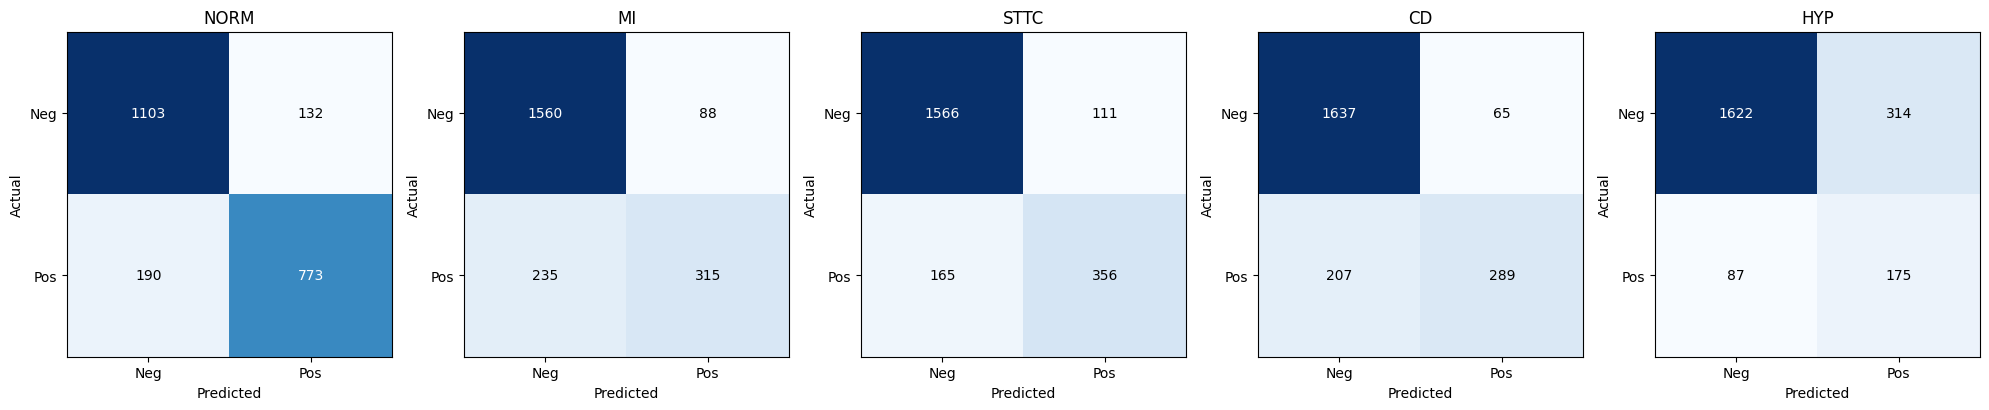

In [ ]:
fig, axes = plt.subplots(1, len(SUPERCLASSES), figsize=(4 * len(SUPERCLASSES), 4))

for i, sc in enumerate(SUPERCLASSES):
    cm = confusion_matrix(y_test[:, i], y_test_pred[:, i])
    axes[i].imshow(cm, cmap="Blues")
    axes[i].set_title(sc)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["Neg", "Pos"])
    axes[i].set_yticklabels(["Neg", "Pos"])
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, cm[r, c], ha="center", va="center",
                         color="white" if cm[r, c] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()


### Per-Class Threshold Tuning

The classification report above uses a fixed 0.5 threshold for every
class, which is rarely optimal for imbalanced classes - especially HYP,
where the model's positive predictions are uncertain (precision and
recall were nearly balanced at 0.5, both around 0.50, in the v1 run).

This sweeps thresholds from 0.05 to 0.95 **on the validation set** (never
the test set, to avoid tuning on data used for the final reported metrics)
and picks the threshold that maximizes F1 for each class independently.
The tuned thresholds are then applied once to the test set for a final,
honest evaluation.


In [ ]:
y_val_pred_proba, _ = model.predict(val_ds)

thresholds_to_try = np.arange(0.05, 0.96, 0.05)
best_thresholds = {}

print("Per-class threshold sweep (selected on validation set):\n")
for i, sc in enumerate(SUPERCLASSES):
    best_f1, best_t = 0.0, 0.5
    for t in thresholds_to_try:
        preds = (y_val_pred_proba[:, i] >= t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds[sc] = best_t
    print(f"  {sc:6s}: best threshold = {best_t:.2f}  (val F1 = {best_f1:.3f}, vs F1 @ 0.5 = "
          f"{f1_score(y_val[:, i], (y_val_pred_proba[:, i] >= 0.5).astype(int), zero_division=0):.3f})")


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step
Per-class threshold sweep (selected on validation set):

  NORM  : best threshold = 0.35  (val F1 = 0.843, vs F1 @ 0.5 = 0.827)
  MI    : best threshold = 0.40  (val F1 = 0.736, vs F1 @ 0.5 = 0.692)
  STTC  : best threshold = 0.45  (val F1 = 0.746, vs F1 @ 0.5 = 0.710)
  CD    : best threshold = 0.40  (val F1 = 0.756, vs F1 @ 0.5 = 0.735)
  HYP   : best threshold = 0.60  (val F1 = 0.478, vs F1 @ 0.5 = 0.454)


In [ ]:
# Apply the tuned thresholds to the TEST set (the held-out set, evaluated once)
threshold_array = np.array([best_thresholds[sc] for sc in SUPERCLASSES])
y_test_pred_tuned = (y_test_pred_proba >= threshold_array).astype(int)

print("Per-class classification report (tuned thresholds):\n")
print(classification_report(y_test, y_test_pred_tuned, target_names=SUPERCLASSES, zero_division=0))

macro_f1_tuned = f1_score(y_test, y_test_pred_tuned, average="macro", zero_division=0)
micro_f1_tuned = f1_score(y_test, y_test_pred_tuned, average="micro", zero_division=0)
print(f"Macro F1 (tuned thresholds): {macro_f1_tuned:.4f}  (vs {macro_f1:.4f} at fixed 0.5)")
print(f"Micro F1 (tuned thresholds): {micro_f1_tuned:.4f}  (vs {micro_f1:.4f} at fixed 0.5)")


Per-class classification report (tuned thresholds):

              precision    recall  f1-score   support

        NORM       0.77      0.94      0.85       963
          MI       0.69      0.77      0.72       550
        STTC       0.73      0.76      0.75       521
          CD       0.75      0.74      0.74       496
         HYP       0.50      0.51      0.50       262

   micro avg       0.72      0.80      0.76      2792
   macro avg       0.69      0.74      0.71      2792
weighted avg       0.71      0.80      0.75      2792
 samples avg       0.74      0.80      0.75      2792

Macro F1 (tuned thresholds): 0.7122  (vs 0.6711 at fixed 0.5)
Micro F1 (tuned thresholds): 0.7556  (vs 0.7054 at fixed 0.5)


## 9. ECG Feature Extraction

The ECG classifier has already been trained. For multimodal fusion, we reuse the learned ECG representation without modifying the original architecture.

This section creates a feature extractor that outputs the latent ECG feature vector from the penultimate Dense layer. These features will later be fused with ECG image, laboratory, and patient metadata features.

In [ ]:

# ECG Feature Extraction

# Reuse the trained ECG model without modifying its architecture.
# The feature vector is taken from the penultimate Dense layer
# (128-dimensional representation) before the final classifier.
# NOTE: `model` has two outputs (diagnosis_output and the attention
# weights from MultiHeadAttentionLayer), so indices below refer to the
# full layer list, not to a specific output head.

from tensorflow.keras.models import Model

# Build a feature extractor from the existing ECG model
ecg_feature_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer(index=-2).output,
    name="ECG_Feature_Extractor"
)

# .summary() already prints to stdout and returns None, so we call it
# directly instead of wrapping it in print(), which used to print an
# extra stray "None" line.
ecg_feature_extractor.summary()


Model: "ECG_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 64)  │        832 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1000, 64)  │          0 │ re_lu[0][0]       │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 1000, 64)  │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 64)  │          0 │ conv1d[0][0],     │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 1000, 64)  │          0 │ re_lu_2[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1000, 64)  │     28,736 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 1000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 1000, 64)  │          0 │ re_lu_3[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1000, 64)  │          0 │ add[0][0],      

 Total params: 373,696 (1.43 MB)

 Trainable params: 372,160 (1.42 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:

# Extract ECG Feature Vectors

# These feature vectors will be reused during multimodal fusion.

# `train_ds` includes oversampling, shuffling, and augmentation (see the
# dataset-building cell in Section 7), so its row count/order does NOT
# match `train_df` (and therefore does not match the ECG image features,
# which are built directly from `train_df`). For feature extraction we
# need a clean, deterministic, 1:1-aligned view of each split, so we
# reuse the existing `make_dataset` helper with shuffle/augment turned off.
train_ds_for_features = make_dataset(X_train, y_train, shuffle=False, augment=False)

ecg_train_features = ecg_feature_extractor.predict(train_ds_for_features, verbose=1)
ecg_val_features   = ecg_feature_extractor.predict(val_ds, verbose=1)
ecg_test_features  = ecg_feature_extractor.predict(test_ds, verbose=1)

print("ECG Train Features :", ecg_train_features.shape)
print("ECG Validation Features :", ecg_val_features.shape)
print("ECG Test Features :", ecg_test_features.shape)


273/273 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
ECG Train Features : (17418, 128)
ECG Validation Features : (2183, 128)
ECG Test Features : (2198, 128)


## 10. ECG Paper Image Generation

Instead of relying on external ECG rendering libraries, each PTB-XL waveform is converted into a standard ECG paper-style image using Matplotlib.

The generated images preserve the waveform morphology and provide a visual representation suitable for the image classification branch.

To reduce storage requirements, the images are generated on-the-fly during training without being saved to disk.

In [ ]:
import cv2

In [ ]:
ECG_IMAGE_SIZE = (224, 224)
def create_ecg_image(ecg_signal):

    canvas_height = 900
    canvas_width = 1200

    canvas = np.ones(
        (canvas_height, canvas_width, 3),
        dtype=np.uint8
    ) * 255

    major_color = (220, 220, 255)
    minor_color = (240, 240, 255)

    minor_step = 10
    major_step = 50

    for x in range(0, canvas_width, minor_step):
        cv2.line(
            canvas,
            (x, 0),
            (x, canvas_height),
            minor_color,
            1
        )

    for y in range(0, canvas_height, minor_step):
        cv2.line(
            canvas,
            (0, y),
            (canvas_width, y),
            minor_color,
            1
        )

    for x in range(0, canvas_width, major_step):
        cv2.line(
            canvas,
            (x, 0),
            (x, canvas_height),
            major_color,
            1
        )

    for y in range(0, canvas_height, major_step):
        cv2.line(
            canvas,
            (0, y),
            (canvas_width, y),
            major_color,
            1
        )

    lead_height = canvas_height // 12

    samples = ecg_signal.shape[0]

    x = np.linspace(
        40,
        canvas_width - 40,
        samples
    ).astype(np.int32)

    for lead in range(12):

        baseline = lead * lead_height + lead_height // 2

        signal = ecg_signal[:, lead]

        signal = signal / (np.max(np.abs(signal)) + 1e-6)

        signal = baseline - signal * (lead_height * 0.35)

        points = np.column_stack(
            (x, signal.astype(np.int32))
        )

        cv2.polylines(
            canvas,
            [points],
            False,
            (0, 0, 0),
            2
        )

    canvas = cv2.resize(
        canvas,
        ECG_IMAGE_SIZE
    )

    canvas = canvas.astype(np.float32) / 255.0

    return canvas

In [ ]:
def load_ecg_image(record_path):

    if isinstance(record_path, bytes):
        record_path = record_path.decode("utf-8")

    signal_raw, _ = wfdb.rdsamp(record_path)

    signal_processed = tf_preprocess_pipeline(
        signal_raw,
        fs=100
    )

    image = create_ecg_image(
        signal_processed
    )

    return image.astype(np.float32)

In [ ]:
def build_record_paths(df):

    return [
        os.path.join(
            PTBXL_PATH,
            filename
        )
        for filename in df["filename_lr"]
    ]

In [ ]:
train_record_paths = build_record_paths(train_df)

val_record_paths = build_record_paths(val_df)

test_record_paths = build_record_paths(test_df)

In [ ]:
def tf_load_ecg_image(record_path):

    image = tf.numpy_function(
        load_ecg_image,
        [record_path],
        tf.float32
    )

    image.set_shape((224, 224, 3))

    return image

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

BATCH_SIZE = 32
def build_image_dataset(record_paths):

    dataset = tf.data.Dataset.from_tensor_slices(
        record_paths
    )

    dataset = dataset.map(
        tf_load_ecg_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [ ]:
train_image_ds = build_image_dataset(
    train_record_paths
)

val_image_ds = build_image_dataset(
    val_record_paths
)

test_image_ds = build_image_dataset(
    test_record_paths
)

## 11. ECG Image Feature Extraction

The generated ECG paper images are passed through a lightweight EfficientNetB0 backbone.

Only the convolutional feature extractor is used to generate compact image embeddings that will later be fused with ECG signal features, laboratory biomarkers, and patient metadata.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
base_image_model = EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224, 224, 3)

)

base_image_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_input = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_image_model(
    image_input,
    training=False
)

image_features = GlobalAveragePooling2D()(x)

image_feature_extractor = Model(

    image_input,

    image_features,

    name="ECG_Image_Feature_Extractor"

)

In [ ]:
CACHE_DIR = "/content/drive/MyDrive/ptb-xl-dataset/multimodal_cache"

os.makedirs(
    CACHE_DIR,
    exist_ok=True
)

In [ ]:
IMAGE_TRAIN_FEATURES_PATH = os.path.join(
    CACHE_DIR,
    "image_train_features.npy"
)

IMAGE_VAL_FEATURES_PATH = os.path.join(
    CACHE_DIR,
    "image_val_features.npy"
)

IMAGE_TEST_FEATURES_PATH = os.path.join(
    CACHE_DIR,
    "image_test_features.npy"
)

In [ ]:
if (
    os.path.exists(IMAGE_TRAIN_FEATURES_PATH)
    and
    os.path.exists(IMAGE_VAL_FEATURES_PATH)
    and
    os.path.exists(IMAGE_TEST_FEATURES_PATH)
):

    print("Loading cached image features...")

    image_train_features = np.load(
        IMAGE_TRAIN_FEATURES_PATH
    )

    image_val_features = np.load(
        IMAGE_VAL_FEATURES_PATH
    )

    image_test_features = np.load(
        IMAGE_TEST_FEATURES_PATH
    )

else:

    print("Extracting ECG image features...")

Extracting ECG image features...


In [ ]:
    image_train_features = image_feature_extractor.predict(

        train_image_ds,

        verbose=1

    )

    np.save(

        IMAGE_TRAIN_FEATURES_PATH,

        image_train_features

    )

545/545 ━━━━━━━━━━━━━━━━━━━━ 284s 489ms/step


In [ ]:
    image_val_features = image_feature_extractor.predict(

        val_image_ds,

        verbose=1

    )

    np.save(

        IMAGE_VAL_FEATURES_PATH,

        image_val_features

    )

69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 617ms/step


In [ ]:
    image_test_features = image_feature_extractor.predict(

        test_image_ds,

        verbose=1

    )

    np.save(

        IMAGE_TEST_FEATURES_PATH,

        image_test_features

    )

69/69 ━━━━━━━━━━━━━━━━━━━━ 47s 678ms/step


In [ ]:
print("Train Image Features Shape :", image_train_features.shape)

print("Validation Image Features Shape :", image_val_features.shape)

print("Test Image Features Shape :", image_test_features.shape)

Train Image Features Shape : (17418, 1280)
Validation Image Features Shape : (2183, 1280)
Test Image Features Shape : (2198, 1280)


## 12. Laboratory Report OCR

Laboratory reports contain valuable clinical biomarkers that complement ECG-based diagnosis.

To keep the system lightweight and scalable, the OCR model is loaded only when a laboratory report is processed. This lazy loading strategy reduces memory consumption during model training and prevents unnecessary resource allocation.

The OCR pipeline is implemented as an independent module, making it reusable in both the notebook and the future web application.

Only a small set of clinically important biomarkers are extracted:

- Troponin
- CK-MB
- BNP
- Creatinine
- HbA1c

The extracted values are converted into a fixed-length numerical feature vector that will later be fused with ECG signal features, ECG image features, and patient metadata.

In [ ]:
try:

    from paddleocr import PaddleOCR

except ImportError:

    !pip install -q paddleocr

import re
import os
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.

In [ ]:
LAB_BIOMARKERS = {

    "troponin": 0,

    "ck-mb": 1,

    "bnp": 2,

    "creatinine": 3,

    "hba1c": 4

}

In [ ]:
# Lazy loading is used to initialize the OCR model only when needed.
# This helps reduce memory usage and avoids loading the model during training.

_ocr_model = None


def get_ocr_model():

    global _ocr_model

    if _ocr_model is None:

        print("Loading PaddleOCR model...")

        _ocr_model = PaddleOCR(

            use_angle_cls=True,

            lang="en",

            show_log=False

        )

    return _ocr_model

In [ ]:
# Extract all readable text from the uploaded laboratory report image.
def extract_report_text(image_path):

    ocr = get_ocr_model()

    result = ocr.ocr(

        image_path,

        cls=True
    )

    extracted_text = []

    for page in result:

        if page is None:
            continue

        for line in page:

            extracted_text.append(

                line[1][0]

            )

    return "\n".join(extracted_text)

In [ ]:
# Extract the required laboratory biomarkers and convert them into
# a fixed-length numerical feature vector.

def extract_lab_features(report_text):

    report_text = report_text.lower()

    feature_vector = np.zeros(

        len(LAB_BIOMARKERS),

        dtype=np.float32
    )

    for biomarker, index in LAB_BIOMARKERS.items():

        pattern = rf"{re.escape(biomarker)}\s*[:=]?\s*([\d\.]+)"

        match = re.search(

            pattern,

            report_text
        )

        if match:

            feature_vector[index] = float(

                match.group(1)
            )

    return feature_vector

In [ ]:
# Complete OCR pipeline:
# Laboratory report image -> OCR -> Text -> Biomarker extraction -> Feature vector
def predict_lab_vector(image_path):

    report_text = extract_report_text(

        image_path
    )

    lab_vector = extract_lab_features(

        report_text
    )

    return lab_vector

##  Patient Metadata Preprocessing

Patient metadata provides additional clinical context that complements ECG signals and laboratory findings.

A lightweight preprocessing pipeline is used to transform structured patient information into a numerical feature vector suitable for multimodal learning.

The preprocessing includes:

- Normalization of numerical attributes
- Encoding of categorical attributes
- Multi-hot encoding of patient symptoms

The generated metadata feature vector will later be fused with the ECG signal features, ECG image features, and laboratory biomarkers.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
NUMERICAL_METADATA = [

    "Age",

    "BloodPressure",

    "HeartRate"

]

CATEGORICAL_METADATA = [

    "Sex"

]

In [ ]:
SUPPORTED_SYMPTOMS = [

    "Chest Pain",

    "Shortness of Breath",

    "Palpitations",

    "Dizziness",

    "Fatigue"

]

In [ ]:
metadata_scaler = MinMaxScaler()

sex_encoder = LabelEncoder()

symptom_encoder = MultiLabelBinarizer(
    classes=SUPPORTED_SYMPTOMS
)

In [ ]:
sex_encoder.fit(

    ["Female", "Male"]

)

symptom_encoder.fit(

    [SUPPORTED_SYMPTOMS]

)



MultiLabelBinarizer(classes=['Chest Pain', 'Shortness of Breath',
                             'Palpitations', 'Dizziness', 'Fatigue'])

In [ ]:
metadata_scaler.fit(

    [

        [0, 80, 40],

        [100, 220, 180]

    ]

)

MinMaxScaler()

In [ ]:
def preprocess_patient_metadata(

    age,

    sex,

    blood_pressure,

    heart_rate,

    symptoms

):

    numerical_features = metadata_scaler.transform(

        [[

            age,

            blood_pressure,

            heart_rate

        ]]

    )[0]

    categorical_feature = sex_encoder.transform(

        [sex]

    )

    symptom_features = symptom_encoder.transform(

        [symptoms]

    )[0]

    metadata_vector = np.concatenate(

        [

            numerical_features,

            categorical_feature,

            symptom_features

        ]

    ).astype(np.float32)

    return metadata_vector

### Example

The following example demonstrates how patient metadata is converted into a numerical feature vector.

In the future web application, these values will be collected through the patient information form before prediction.

In [ ]:
sample_metadata = preprocess_patient_metadata(

    age=58,

    sex="Male",

    blood_pressure=145,

    heart_rate=92,

    symptoms=[

        "Chest Pain",

        "Fatigue"

    ]

)

print(sample_metadata)

print(sample_metadata.shape)

[0.58       0.4642857  0.37142858 1.         1.         0.
 0.         0.         1.        ]
(9,)


## 14. ECG Feature Extraction

The trained ECG model is reused as a feature extractor.

Instead of using the final diagnosis layer, the intermediate ECG feature representation is extracted from the bottleneck layer.

These feature vectors will later be fused with ECG image features, laboratory biomarkers, and patient metadata.

In [ ]:

# NOTE: This duplicates Section 9 above, which already built
# `ecg_feature_extractor` from the correct layer
# (model.get_layer(index=-2), i.e. "ecg_feature_vector"/dropout_4).
# The original code here referenced a layer named "dense_3", which
# does not exist in this architecture and raised a ValueError.
# Rebuilding a second extractor would also risk it silently drifting
# out of sync with the one used everywhere else in the notebook, so
# we simply reuse the existing extractor instead of rebuilding it.
print("Reusing ecg_feature_extractor from Section 9:", ecg_feature_extractor.name)


Reusing ecg_feature_extractor from Section 9: ECG_Feature_Extractor


In [ ]:

# NOTE: The original code here called
#   ecg_feature_extractor.predict(X_train, batch_size=batch_size, ...)
# but `batch_size` was never defined anywhere in the notebook, which
# raised a NameError. It also duplicated the extraction already done
# in Section 9. We simply reuse the feature arrays computed there.
print("ECG Train Features :", ecg_train_features.shape)
print("ECG Validation Features :", ecg_val_features.shape)
print("ECG Test Features :", ecg_test_features.shape)


ECG Train Features : (17418, 128)
ECG Validation Features : (2183, 128)
ECG Test Features : (2198, 128)


In [ ]:
np.save(

    "ecg_train_features.npy",

    ecg_train_features

)

np.save(

    "ecg_val_features.npy",

    ecg_val_features

)

np.save(

    "ecg_test_features.npy",

    ecg_test_features

)

print("ECG feature vectors saved successfully.")

ECG feature vectors saved successfully.


## 15. Feature Projection

The ECG image branch produces a 1280-dimensional feature vector.

To balance the contribution of each modality and reduce computational cost, the image features are projected into a lower-dimensional embedding before multimodal fusion.

This projection layer is trained jointly with the multimodal classifier.

In [ ]:
image_feature_input = tf.keras.Input(

    shape=(1280,),

    name="image_feature_input"

)

projected_image_features = layers.Dense(

    128,

    activation="relu",

    name="image_feature_projection"

)(image_feature_input)

image_projection_model = tf.keras.Model(

    image_feature_input,

    projected_image_features

)

In [ ]:

# Project the raw 1280-D EfficientNet image features down to 128-D
# using the projection model built above. This step was missing in
# the original notebook, which caused a NameError on
# `projected_train_image_features` (and val/test) below.
projected_train_image_features = image_projection_model.predict(image_train_features, verbose=1)
projected_val_image_features   = image_projection_model.predict(image_val_features, verbose=1)
projected_test_image_features  = image_projection_model.predict(image_test_features, verbose=1)

print(
    "Projected Train Image Features :",
    projected_train_image_features.shape
)

print(
    "Projected Validation Image Features :",
    projected_val_image_features.shape
)

print(
    "Projected Test Image Features :",
    projected_test_image_features.shape
)


545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Projected Train Image Features : (17418, 128)
Projected Validation Image Features : (2183, 128)
Projected Test Image Features : (2198, 128)


## 16. Multimodal Feature Fusion

The final prediction is obtained by combining information from all available modalities.

Each modality contributes different clinical information:

- ECG signal features capture temporal cardiac activity.
- ECG image features capture the visual morphology of the waveform.
- Laboratory biomarkers provide biochemical evidence.
- Patient metadata supplies additional clinical context.

A lightweight fusion strategy is adopted by concatenating all feature vectors and learning a shared representation using fully connected layers.

This modular design allows each branch to be improved independently without changing the overall architecture.

In [ ]:
# ===============================
# Future Integration Notes
# ===============================
#
# This fusion model is intentionally designed to be modular.
#
# During deployment, the web application should:
#
# 1. Generate ECG signal embeddings.
# 2. Generate ECG image embeddings.
# 3. Extract laboratory biomarkers using OCR.
# 4. Preprocess patient metadata.
# 5. Pass all feature vectors to this fusion model.
#
# The output of this model represents the final diagnostic prediction
# and can later be connected to the report generation module.

# `num_classes` (lowercase) is referenced below and in the deployment
# config cell, but only `NUM_CLASSES` (uppercase, from Section 7) was
# ever defined - this alias fixes the resulting NameError.
num_classes = NUM_CLASSES

ecg_feature_input = tf.keras.Input(
    shape=(128,),
    name="ecg_feature_input"
)

image_feature_input = tf.keras.Input(
    shape=(128,),
    name="image_feature_input"
)

lab_feature_input = tf.keras.Input(
    shape=(5,),
    name="lab_feature_input"
)

metadata_feature_input = tf.keras.Input(
    shape=(9,),
    name="metadata_feature_input"
)


In [ ]:
# Concatenate all modality feature vectors into one shared representation.

fusion_features = layers.Concatenate(

    name="feature_fusion"

)(

    [

        ecg_feature_input,

        image_feature_input,

        lab_feature_input,

        metadata_feature_input

    ]

)

In [ ]:
# Learn interactions between the different modalities
# using lightweight fully connected layers.

x = layers.Dense(

    256,

    activation="relu",

    name="fusion_dense_1"

)(fusion_features)

x = layers.Dropout(

    0.4,

    name="fusion_dropout"

)(x)

x = layers.Dense(

    128,

    activation="relu",

    name="fusion_dense_2"

)(x)

In [ ]:
# Final multilabel prediction layer.
#
# The number of output classes matches the ECG classifier.

fusion_output = layers.Dense(

    num_classes,

    activation="sigmoid",

    name="fusion_prediction"

)(x)

In [ ]:
fusion_model = tf.keras.Model(

    inputs=[

        ecg_feature_input,

        image_feature_input,

        lab_feature_input,

        metadata_feature_input

    ],

    outputs=fusion_output,

    name="CardioGuard_Multimodal_Fusion"

)



In [ ]:
fusion_model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-4

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(

            name="auc"

        )

    ]

)

In [ ]:
# Verify the multimodal architecture before training.

fusion_model.summary()

Model: "CardioGuard_Multimodal_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_feature_input   │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_feature_input │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lab_feature_input   │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_feature_i… │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 270)       │          0 │ ecg_feature_inpu… │
│ (Concatenate)       │                   │            │ image_feature_in… │
│                     │                   │            │ lab_feature_inpu… │
│                     │                   │            │ metadata_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 256)       │     69,376 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 256)       │          0 │ fusion_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_2      │ (None, 128)       │     32,896 │ fusion_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_prediction   │ (None, 5)         │        645 │ fusion_dense_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,917 (402.02 KB)

 Trainable params: 102,917 (402.02 KB)

 Non-trainable params: 0 (0.00 B)

## 16. Train Multimodal Fusion Model

The multimodal fusion model is trained after all feature vectors have been prepared.

For demonstration purposes, laboratory and metadata features may be simulated when real multimodal datasets are unavailable.

The training procedure remains identical and can later be repeated using real patient data without modifying the model architecture.

In [ ]:
# ============================================================
# Train Fusion Model
# ============================================================
#
# During production this model will receive:
#
# ECG Features
# ECG Image Features
# Laboratory Features
# Metadata Features
#
# and produce the final diagnosis.
#
# ============================================================

# ------------------------------------------------------------------
# SIMULATED lab + metadata features (placeholder only)
# ------------------------------------------------------------------
# PTB-XL does not include paired laboratory reports or patient
# metadata for each ECG record, so `lab_train_features` /
# `metadata_train_features` (and val/test) were undefined in the
# original notebook. As noted in this section's markdown cell, we
# simulate them here so the fusion architecture can be exercised
# end-to-end. Replace this block with real OCR/metadata pipelines
# (predict_lab_vector / preprocess_patient_metadata) once paired
# clinical data is available - do NOT ship these random values to
# production.
_rng = np.random.default_rng(42)

def _simulate_lab_features(n_samples):
    # Rough plausible ranges for troponin, CK-MB, BNP, creatinine, HbA1c
    ranges = np.array([
        [0.0, 0.5],    # troponin (ng/mL)
        [0.0, 25.0],   # CK-MB (ng/mL)
        [0.0, 400.0],  # BNP (pg/mL)
        [0.5, 1.5],    # creatinine (mg/dL)
        [4.5, 9.0],    # HbA1c (%)
    ])
    lo, hi = ranges[:, 0], ranges[:, 1]
    return _rng.uniform(lo, hi, size=(n_samples, len(LAB_BIOMARKERS))).astype(np.float32)

def _simulate_metadata_features(n_samples):
    vectors = []
    for _ in range(n_samples):
        age = int(_rng.integers(18, 90))
        sex = "Male" if _rng.random() < 0.5 else "Female"
        blood_pressure = int(_rng.integers(90, 180))
        heart_rate = int(_rng.integers(50, 140))
        n_symptoms = int(_rng.integers(0, 3))
        symptoms = list(_rng.choice(SUPPORTED_SYMPTOMS, size=n_symptoms, replace=False))
        vectors.append(
            preprocess_patient_metadata(age, sex, blood_pressure, heart_rate, symptoms)
        )
    return np.stack(vectors).astype(np.float32)

lab_train_features = _simulate_lab_features(ecg_train_features.shape[0])
lab_val_features    = _simulate_lab_features(ecg_val_features.shape[0])
lab_test_features   = _simulate_lab_features(ecg_test_features.shape[0])

metadata_train_features = _simulate_metadata_features(ecg_train_features.shape[0])
metadata_val_features    = _simulate_metadata_features(ecg_val_features.shape[0])
metadata_test_features   = _simulate_metadata_features(ecg_test_features.shape[0])

print("Simulated lab features      :", lab_train_features.shape, lab_val_features.shape, lab_test_features.shape)
print("Simulated metadata features :", metadata_train_features.shape, metadata_val_features.shape, metadata_test_features.shape)

history_fusion = fusion_model.fit(
    [
        ecg_train_features,
        projected_train_image_features,
        lab_train_features,
        metadata_train_features
    ],
    y_train,
    validation_data=(
        [
            ecg_val_features,
            projected_val_image_features,
            lab_val_features,
            metadata_val_features
        ],
        y_val
    ),
    epochs=15,
    batch_size=64,
    verbose=1
)


Simulated lab features      : (17418, 5) (2183, 5) (2198, 5)
Simulated metadata features : (17418, 9) (2183, 9) (2198, 9)
Epoch 1/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.3362 - auc: 0.5750 - loss: 1.7108 - val_accuracy: 0.5483 - val_auc: 0.7352 - val_loss: 0.6197
Epoch 2/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4636 - auc: 0.6769 - loss: 0.8823 - val_accuracy: 0.6221 - val_auc: 0.8273 - val_loss: 0.4507
Epoch 3/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5735 - auc: 0.7832 - loss: 0.5869 - val_accuracy: 0.6853 - val_auc: 0.8781 - val_loss: 0.3696
Epoch 4/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6567 - auc: 0.8547 - loss: 0.4380 - val_accuracy: 0.7027 - val_auc: 0.8951 - val_loss: 0.3459
Epoch 5/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6988 - auc: 0.8878 - loss: 0.3710 - val_accuracy: 0.7164 - val_auc: 0.9080 - val_loss: 0.3277
Epoch 6/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7267 - auc

In [ ]:
# ============================================================
# Evaluate Fusion Model
# ============================================================

fusion_results = fusion_model.evaluate(
    [
        ecg_test_features,
        projected_test_image_features,
        lab_test_features,
        metadata_test_features
    ],
    y_test,
    verbose=1
)

print()

for name, value in zip(
    fusion_model.metrics_names,
    fusion_results
):
    print(f"{name}: {value:.4f}")


69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7038 - auc: 0.9188 - loss: 0.3170

loss: 0.3170
compile_metrics: 0.7038


## 17. Explainable AI (XAI)

To improve transparency, CardioGuard AI provides explanations for the final multimodal prediction.

The explainability module includes:

- SHAP for the multimodal fusion model.
- Grad-CAM for the ECG image branch.

Together, these methods explain both the overall decision and the visual evidence used by the image model.

In [ ]:
try:

    import shap

except ImportError:

    !pip install -q shap

    import shap

import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# Explainable AI Module
# ============================================================
#
# This module is responsible for explaining the FINAL prediction
# generated by the multimodal fusion model.
#
# During deployment the workflow will be:
#
# User Upload
#      │
#      ▼
# ECG Signal
# ECG Image
# Laboratory Report
# Patient Metadata
#      │
#      ▼
# Feature Extraction
#      │
#      ▼
# Fusion Model Prediction
#      │
#      ├────────► Prediction returned to API
#      │
#      └────────► SHAP Explanation
#
# The explanation object can later be:
#
# • returned directly by the REST API
# • published through Kafka
# • stored inside Azure Blob Storage
# • summarized by the RAG pipeline
# • displayed in the clinician dashboard
#
# This module does NOT perform inference.
# It only explains predictions that already exist.
#
# ============================================================

In [ ]:
def explain_fusion_prediction(

    fusion_model,

    background_data,

    sample_data

):

    # background_data
    #
    # Small representative samples used by SHAP
    # to estimate the contribution of each modality.
    #
    # Typical size:
    # 50 - 200 samples.

    explainer = shap.Explainer(

        fusion_model,

        background_data

    )

    # sample_data contains the patient that needs
    # an explanation after prediction.

    shap_values = explainer(

        sample_data

    )

    return shap_values

In [ ]:
# ============================================================
# Future Backend Integration
# ============================================================
#
# The backend should call this function AFTER
# obtaining the final diagnosis.
#
# Example Production Workflow
#
# Client
#    │
#    ▼
# FastAPI
#    │
#    ▼
# ECG Model
#    │
#    ▼
# Image Model
#    │
#    ▼
# OCR Pipeline
#    │
#    ▼
# Metadata Processing
#    │
#    ▼
# Fusion Model
#    │
#    ├────────► Diagnosis
#    │
#    └────────► SHAP Explanation
#
# The returned SHAP values may later be:
#
# • serialized as JSON
# • sent through Kafka topics
# • stored in Azure
# • consumed by the RAG service
# • displayed inside the web dashboard
#
# ============================================================

# Example
#
# background_data = [
#     ecg_train_features[:100],
#     projected_train_image_features[:100],
#     lab_train_features[:100],
#     metadata_train_features[:100]
# ]
#
# sample_data = [
#     ecg_test_features[:1],
#     projected_test_image_features[:1],
#     lab_test_features[:1],
#     metadata_test_features[:1]
# ]
#
# shap_values = explain_fusion_prediction(
#     fusion_model,
#     background_data,
#     sample_data
# )
#
# shap.plots.bar(shap_values)

## 18. Grad-CAM Visualization

Grad-CAM provides a visual explanation for the ECG image branch by highlighting the image regions that contribute most to the prediction.

Unlike SHAP, Grad-CAM is specific to convolutional neural networks and is only applied to the ECG image model.

This module is independent from training and is executed only when an explanation is requested.

In [ ]:
# ============================================================
# Grad-CAM Utilities
# ============================================================
#
# This module generates visual explanations for the ECG image
# classification branch.
#
# During deployment:
#
# ECG Image
#     │
#     ▼
# Image Model
#     │
#     ▼
# Prediction
#     │
#     └────────► Grad-CAM Heatmap
#
# The generated heatmap can later be:
#
# • displayed inside the web application
# • stored in Azure Blob Storage
# • attached to the generated medical report
# • returned through the REST API
#
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
def make_gradcam_heatmap(

    image,

    model,

    last_conv_layer_name

):

    # Build a temporary model that returns both:
    #
    # 1. Last convolution feature maps
    # 2. Final predictions

    grad_model = tf.keras.Model(

        model.inputs,

        [

            model.get_layer(last_conv_layer_name).output,

            model.output

        ]

    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image)

        class_index = tf.argmax(predictions[0])

        loss = predictions[:, class_index]

    gradients = tape.gradient(

        loss,

        conv_outputs

    )

    pooled_gradients = tf.reduce_mean(

        gradients,

        axis=(0, 1, 2)

    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(

        pooled_gradients * conv_outputs,

        axis=-1

    )

    heatmap = tf.maximum(

        heatmap,

        0

    )

    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

In [ ]:
def display_gradcam(

    image,

    heatmap,

    alpha=0.4

):

    # Resize the heatmap to the original image size.

    heatmap = cv2.resize(

        heatmap,

        (

            image.shape[1],

            image.shape[0]

        )

    )

    heatmap = np.uint8(

        255 * heatmap

    )

    heatmap = cv2.applyColorMap(

        heatmap,

        cv2.COLORMAP_JET

    )

    overlay = cv2.addWeighted(

        image,

        1.0,

        heatmap,

        alpha,

        0

    )

    plt.figure(figsize=(8,8))

    plt.imshow(

        cv2.cvtColor(

            overlay,

            cv2.COLOR_BGR2RGB

        )

    )

    plt.axis("off")

    plt.show()

In [ ]:
# ============================================================
# Future Backend Integration
# ============================================================
#
# After the image model produces its prediction,
# the backend may optionally generate Grad-CAM.
#
# Suggested workflow:
#
# Uploaded ECG Image
#        │
#        ▼
# EfficientNet Model
#        │
#        ▼
# Prediction
#        │
#        ├────────► Diagnosis
#        │
#        └────────► Grad-CAM Heatmap
#
# The heatmap can later be:
#
# • returned by FastAPI
# • stored in Azure Blob Storage
# • embedded inside the PDF report
# • displayed inside the clinician dashboard
#
# ============================================================

# Example
#
# heatmap = make_gradcam_heatmap(
#     sample_image,
#     image_model,
#     "top_conv"
# )
#
# display_gradcam(
#     original_image,
#     heatmap
# )

## 19. Deployment Preparation

The following section exports all reusable components required for deployment.

Instead of rebuilding or retraining the models, the backend can directly load these saved artifacts.

The exported components include:

- ECG classification model
- ECG image feature extractor
- Image feature projection model
- Multimodal fusion model
- Metadata preprocessing objects

These files are intended to be consumed by the future backend services (FastAPI, Kafka, Azure, and the report generation pipeline).

In [ ]:
# ============================================================
# Create Deployment Directory
# ============================================================
#
# All exported models and preprocessing objects will be stored
# inside a single directory.
#
# The backend team can package this directory with the
# deployed application or upload it to Azure Blob Storage.
#
# ============================================================

import os

DEPLOYMENT_DIR = "cardioguard_models"

os.makedirs(

    DEPLOYMENT_DIR,

    exist_ok=True

)

In [ ]:
# ============================================================
# Save TensorFlow Models
# ============================================================
#
# Each model is saved independently.
#
# This allows the backend to load only the required model
# instead of loading the complete notebook.
#
# ECG Model
#      ↓
# ECG Prediction
#
# ECG Feature Extractor
#      ↓
# 128-D ECG Embedding (fusion input)
#
# Image Projection Model
#      ↓
# Image Embeddings
#
# Fusion Model
#      ↓
# Final Diagnosis
#
# ============================================================

model.save(
    os.path.join(
        DEPLOYMENT_DIR,
        "ecg_model.keras"
    )
)

# Needed by the backend to turn a raw ECG signal into the 128-D
# feature vector the fusion model expects - this was missing from the
# original export list even though the fusion model depends on it.
ecg_feature_extractor.save(
    os.path.join(
        DEPLOYMENT_DIR,
        "ecg_feature_extractor.keras"
    )
)

image_projection_model.save(
    os.path.join(
        DEPLOYMENT_DIR,
        "image_projection_model.keras"
    )
)

fusion_model.save(
    os.path.join(
        DEPLOYMENT_DIR,
        "fusion_model.keras"
    )
)

# Weights saved separately as well, as requested, in addition to the
# full model above.
fusion_model.save_weights(
    os.path.join(
        DEPLOYMENT_DIR,
        "fusion_model.weights.h5"
    )
)


In [ ]:
# ============================================================
# Save Metadata Preprocessing Objects
# ============================================================
#
# These preprocessing objects MUST remain synchronized
# with the models used during training.
#
# During deployment the backend should load these objects
# before preprocessing user metadata.
#
# ============================================================

import joblib

joblib.dump(

    metadata_scaler,

    os.path.join(

        DEPLOYMENT_DIR,

        "metadata_scaler.pkl"

    )

)

joblib.dump(

    sex_encoder,

    os.path.join(

        DEPLOYMENT_DIR,

        "sex_encoder.pkl"

    )

)

joblib.dump(

    symptom_encoder,

    os.path.join(

        DEPLOYMENT_DIR,

        "symptom_encoder.pkl"

    )

)

['cardioguard_models/symptom_encoder.pkl']

In [ ]:
# ============================================================
# Save Feature Extraction Configuration
# ============================================================
#
# These parameters are required by the backend to reproduce
# the same preprocessing pipeline used during development.
#
# Updating these values without retraining the models
# may lead to inconsistent predictions.
#
# ============================================================

deployment_config = {
    # NOTE: the original code referenced `IMAGE_SIZE`, which was never
    # defined - the image size actually used throughout the notebook
    # is `ECG_IMAGE_SIZE` (Section 10).
    "image_size": ECG_IMAGE_SIZE,
    "num_classes": num_classes,
    "superclasses": SUPERCLASSES,
    # Per-class thresholds tuned on the validation set (Section 8) -
    # the backend needs these to binarize fusion-model probabilities
    # the same way this notebook does, instead of assuming 0.5 for
    # every class.
    "class_thresholds": best_thresholds,
    "lab_features": list(
        LAB_BIOMARKERS.keys()
    ),
    "metadata_features": [
        "Age",
        "BloodPressure",
        "HeartRate",
        "Sex",
        "Symptoms"
    ]
}

joblib.dump(
    deployment_config,
    os.path.join(
        DEPLOYMENT_DIR,
        "deployment_config.pkl"
    )
)


['cardioguard_models/deployment_config.pkl']

In [ ]:
# ============================================================
# Save ECG Image Feature Extractor
# ============================================================
#
# The image feature extractor converts ECG paper images into
# high-level feature embeddings.
#
# During deployment:
#
# Uploaded ECG Image
#        │
#        ▼
# Image Feature Extractor
#        │
#        ▼
# 1280-D Image Features
#        │
#        ▼
# Image Projection Model
#        │
#        ▼
# 128-D Image Embedding
#        │
#        ▼
# Multimodal Fusion Model
#
# Saving the image feature extractor separately allows the
# backend to reuse it without rebuilding the notebook.
#
# ============================================================

image_feature_extractor.save(

    os.path.join(

        DEPLOYMENT_DIR,

        "image_feature_extractor.keras"

    )

)

In [ ]:
# ============================================================
# Export Summary
# ============================================================
#
# Expected deployment directory:
#
# cardioguard_models/
#
# ├── ecg_model.keras
# ├── ecg_feature_extractor.keras
# ├── image_feature_extractor.keras
# ├── image_projection_model.keras
# ├── fusion_model.keras
# ├── fusion_model.weights.h5
# ├── metadata_scaler.pkl
# ├── sex_encoder.pkl
# ├── symptom_encoder.pkl
# └── deployment_config.pkl
#
# Backend Integration
# -------------------
#
# 1. Load ecg_model.keras
#    -> Use for standalone ECG diagnosis, if needed.
#
# 2. Load ecg_feature_extractor.keras
#    -> Extract the 128-D ECG signal feature vector for fusion.
#
# 3. Load image_feature_extractor.keras
#    -> Extract ECG image features.
#
# 4. Load image_projection_model.keras
#    -> Convert image embeddings to 128-D.
#
# 5. Load metadata preprocessing objects (metadata_scaler.pkl,
#    sex_encoder.pkl, symptom_encoder.pkl) and deployment_config.pkl.
#
# 6. Load fusion_model.keras (or rebuild from the architecture and
#    load fusion_model.weights.h5)
#    -> Generate the final diagnosis, then apply
#       deployment_config["class_thresholds"] per class.
#
# These exported artifacts are intended for:
#
# • FastAPI inference services
# • Docker deployment
# • Azure Machine Learning
# • Azure Blob Storage
# • Kafka consumers
# • Report generation services
#
# ============================================================

print("Deployment package created successfully.")

print()

for file in sorted(os.listdir(DEPLOYMENT_DIR)):

    print(file)


Deployment package created successfully.

deployment_config.pkl
ecg_feature_extractor.keras
ecg_model.keras
fusion_model.keras
fusion_model.weights.h5
image_feature_extractor.keras
image_projection_model.keras
metadata_scaler.pkl
sex_encoder.pkl
symptom_encoder.pkl
